# Bloc 3B — Prevision de la charge par ETP

Analyse exploratoire de `features_journalier` pour la cible `charge_par_etp`
(dossiers en attente rapportes au nombre d'ETP disponibles ce jour-la) et
diagnostic d'apprentissage du modele retenu en production
(`models/model_charge_etp.pkl`). C'est le seul des 4 blocs ou la version
"amelioree" ne bat pas la meilleure configuration d'origine sur le jeu de
test (cf. `docs/AMELIORATION_MODELES.md`, Bloc 3B) : ce notebook sert aussi a
verifier, du cote des donnees, si ce resultat mitige s'explique par autre
chose qu'un simple manque de reglage.

In [1]:
from _setup import engine, save, PROJECT_ROOT, COULEUR_PRINCIPALE, COULEUR_ALERTE, COULEUR_NEUTRE
import sys
sys.path.insert(0, str(PROJECT_ROOT / "notebooks_avec_ecriture_dans_database"))
from modelisation_common import calculer_features_incidents, split_temporel

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BLOC = "charge_etp"
TARGET = "charge_par_etp"
FEATURES_BASE = [
    "volume_lag_1j", "volume_lag_7j", "volume_lag_14j", "volume_lag_30j",
    "etp_lag_1j", "etp_lag_7j", "etp_lag_14j", "etp_lag_30j",
    "volume_moy_7j", "charge_moy_7j",
    "jour_semaine", "mois", "trimestre", "semaine_du_mois",
    "est_fin_de_mois", "est_fin_trimestre", "est_lundi", "est_vendredi",
    "etp_disponible", "taux_complexes",
    "nb_etp_impactes_jour", "volume_annonce_jour",
]
FEATURES_CYCLIQUES = ["jour_semaine_sin", "jour_semaine_cos", "mois_sin", "mois_cos"]
FEATURES = FEATURES_BASE + FEATURES_CYCLIQUES

df = pd.read_sql("SELECT * FROM features_journalier", engine, parse_dates=["date"])
df = df.sort_values("date").reset_index(drop=True)
for c in df.columns:
    if c != "date":
        df[c] = pd.to_numeric(df[c], errors="coerce")
df["jour_semaine_sin"] = np.sin(2 * np.pi * df["jour_semaine"] / 7)
df["jour_semaine_cos"] = np.cos(2 * np.pi * df["jour_semaine"] / 7)
df["mois_sin"] = np.sin(2 * np.pi * df["mois"] / 12)
df["mois_cos"] = np.cos(2 * np.pi * df["mois"] / 12)
df = df.merge(calculer_features_incidents(df["date"], engine), on="date", how="left")

print(df[TARGET].describe().round(2))

count    640.00
mean      80.82
std       22.99
min       37.43
25%       63.77
50%       78.12
75%       95.03
max      171.09
Name: charge_par_etp, dtype: float64


**Lecture.** `charge_par_etp` moyenne 80.8 dossiers par ETP, avec un ecart-type
de 23.0 (min 37.4, max 171.1) : sur les journees les plus chargees, un ETP
porte plus de quatre fois la charge des journees les plus calmes. C'est une
cible nettement plus volatile en proportion que le volume brut du bloc 3A
(coefficient de variation ~28% pour le volume, ~28% aussi ici en apparence,
mais avec un maximum a plus du double de la mediane -- signe d'une queue de
distribution plus etiree, probablement les jours de cloture ou l'ETP
disponible ne suit pas la meme hausse que le volume).

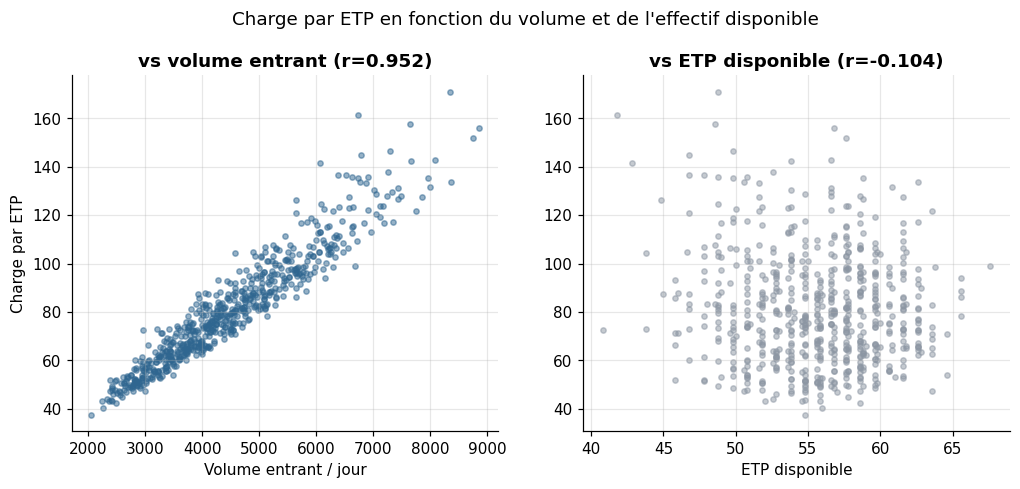

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].scatter(df["volume_entrant_jour"], df[TARGET], s=12, alpha=0.5, color=COULEUR_PRINCIPALE)
axes[0].set_xlabel("Volume entrant / jour")
axes[0].set_ylabel("Charge par ETP")
axes[0].set_title(f"vs volume entrant (r={df[TARGET].corr(df['volume_entrant_jour']):.3f})")

axes[1].scatter(df["etp_disponible"], df[TARGET], s=12, alpha=0.5, color=COULEUR_NEUTRE)
axes[1].set_xlabel("ETP disponible")
axes[1].set_title(f"vs ETP disponible (r={df[TARGET].corr(df['etp_disponible']):.3f})")
fig.suptitle("Charge par ETP en fonction du volume et de l'effectif disponible", y=1.02)
save(fig, BLOC, "01_scatter_volume_etp.png")
plt.show()

**Lecture.** La relation avec le volume entrant est quasiment lineaire et
tres forte (r=0.952) -- attendu, puisque la charge par ETP est construite a
partir du volume rapporte a l'effectif. La relation avec l'ETP disponible
lui-meme est, a l'inverse, faible et legerement negative (r=-0.104) : les
jours ou l'effectif disponible est plus important ne sont pas franchement les
jours les moins charges. Deux lectures possibles, non tranchees par ces
seules donnees : soit l'effectif est ajuste avec un decalage par rapport a la
demande reelle, soit l'effectif fluctue surtout pour des raisons
independantes du volume (conges, absences) qui n'ont pas de lien direct avec
les pics d'activite. Dans les deux cas, ca confirme que le volume (et son
historique recent) porte l'essentiel du signal, pas l'effectif.

Lignes utilisables : 610 / 640
nb_etp_impactes_jour non nul : 0 / 640
volume_annonce_jour non nul  : 0 / 640


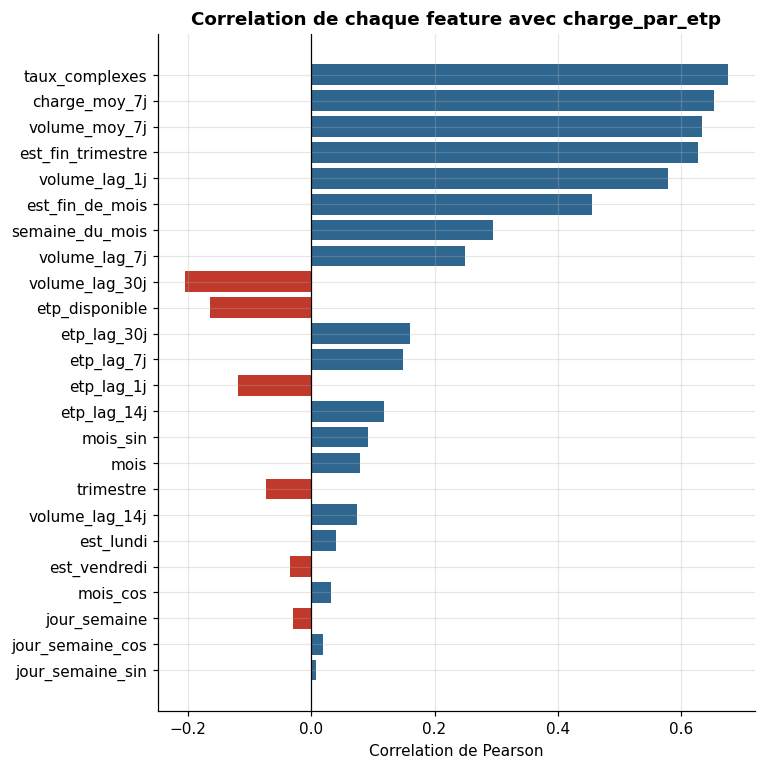

In [3]:
df_model = df[FEATURES + [TARGET, "date"]].dropna().copy()
print(f"Lignes utilisables : {len(df_model)} / {len(df)}")
print(f"nb_etp_impactes_jour non nul : {(df['nb_etp_impactes_jour'] != 0).sum()} / {len(df)}")
print(f"volume_annonce_jour non nul  : {(df['volume_annonce_jour'] != 0).sum()} / {len(df)}")

corr_target = df_model[FEATURES + [TARGET]].corr()[TARGET].drop(TARGET)
corr_target = corr_target.dropna().sort_values(key=np.abs, ascending=False)

fig, ax = plt.subplots(figsize=(7, 8))
couleurs = [COULEUR_ALERTE if v < 0 else COULEUR_PRINCIPALE for v in corr_target.values]
ax.barh(corr_target.index[::-1], corr_target.values[::-1], color=couleurs[::-1])
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Correlation de chaque feature avec charge_par_etp")
ax.set_xlabel("Correlation de Pearson")
save(fig, BLOC, "02_correlations_features.png")
plt.show()

**Lecture.** `nb_etp_impactes_jour` et `volume_annonce_jour` sont nuls sur
les 640 jours de l'historique (0 valeur non nulle) : leur correlation avec la
cible n'est meme pas calculable (variance nulle), et c'est normal -- ce sont
les deux regresseurs issus de la page /incidents de l'app, qui restent a
zero tant qu'aucun manager n'a saisi d'incident ETP ou d'annonce d'activite.
Ils sont donc presents dans les features mais inertes sur ces donnees
synthetiques ; ils redeviendront actifs des que la table `incidents_manager`
se peuplera. Sur le reste des variables, `taux_complexes` arrive en tete
(r=0.675), suivi de `charge_moy_7j` (0.654) et `volume_moy_7j` (0.634) --
sans surprise, la charge recente et la part de dossiers complexes sont plus
informatives que n'importe quelle variable calendaire isolee. `est_fin_trimestre`
reste tout de meme a 0.626, confirmant l'effet deja observe sur le volume brut.
A l'oppose, les quatre features cycliques (sin/cos) ajoutees lors du portage
plafonnent toutes sous 0.10 de correlation -- ce qui, lu ici, donne une
explication concrete a un constat deja pose dans `AMELIORATION_MODELES.md`
("les features cycliques n'apportent pas de gain mesurable ici") : le signal
lineaire qu'elles portent est, sur ces donnees, quasi nul des le depart.

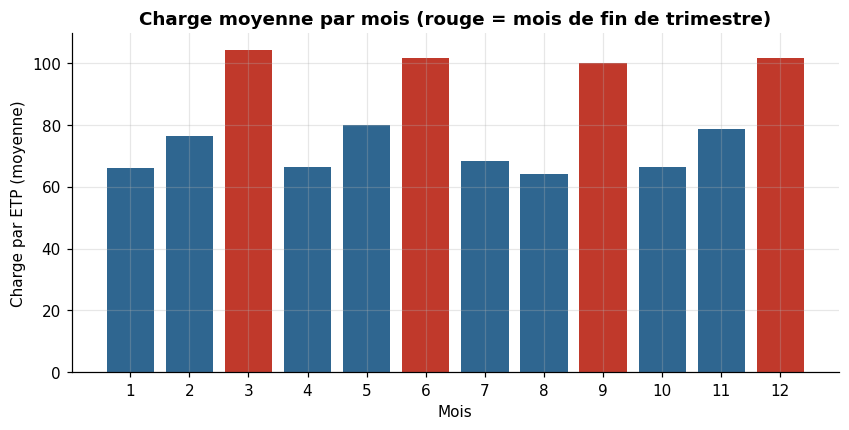

In [4]:
charge_mois = df.groupby("mois")[TARGET].mean()
fig, ax = plt.subplots(figsize=(9, 4))
mois_fin_trimestre = {3, 6, 9, 12}
couleurs = [COULEUR_ALERTE if m in mois_fin_trimestre else COULEUR_PRINCIPALE for m in charge_mois.index]
ax.bar(charge_mois.index, charge_mois.values, color=couleurs)
ax.set_xticks(range(1, 13))
ax.set_xlabel("Mois")
ax.set_ylabel("Charge par ETP (moyenne)")
ax.set_title("Charge moyenne par mois (rouge = mois de fin de trimestre)")
save(fig, BLOC, "03_charge_par_mois.png")
plt.show()

**Lecture.** Les quatre mois de cloture trimestrielle (mars, juin, septembre,
decembre, en rouge) ressortent nettement au-dessus des autres : entre 99.8
et 104.4 en moyenne, contre 63.9 a 79.9 le reste de l'annee. Aout est le mois
le plus calme (64.0), coherent avec la baisse de volume deja observee dans le
bloc 3A. La saisonnalite hebdomadaire, elle, reste marginale ici aussi (de
79.0 le vendredi a 82.6 le lundi) -- meme lecture que pour le volume brut :
une fois qu'on se limite aux jours ouvres, le vrai decoupage pertinent est le
cycle mensuel/trimestriel, pas le jour de la semaine.

## Courbe d'apprentissage (XGBoost retenu)

Contrairement au bloc 3A, la cible ici n'est pas une serie a prevoir par
recurrence : chaque ligne de `features_journalier` porte deja ses propres
lags precalcules, donc une fenetre expansive chronologique suffit -- on
entraine XGBoost (`max_depth=3`, `learning_rate=0.1`, hyperparametres retenus
dans `model_charge_etp.pkl`, `n_estimators` fixe a la meilleure iteration
d'early stopping du modele de production, 29) sur les N premiers jours du
train et on evalue systematiquement sur le meme jeu de validation.

train=427  val=91  test=92


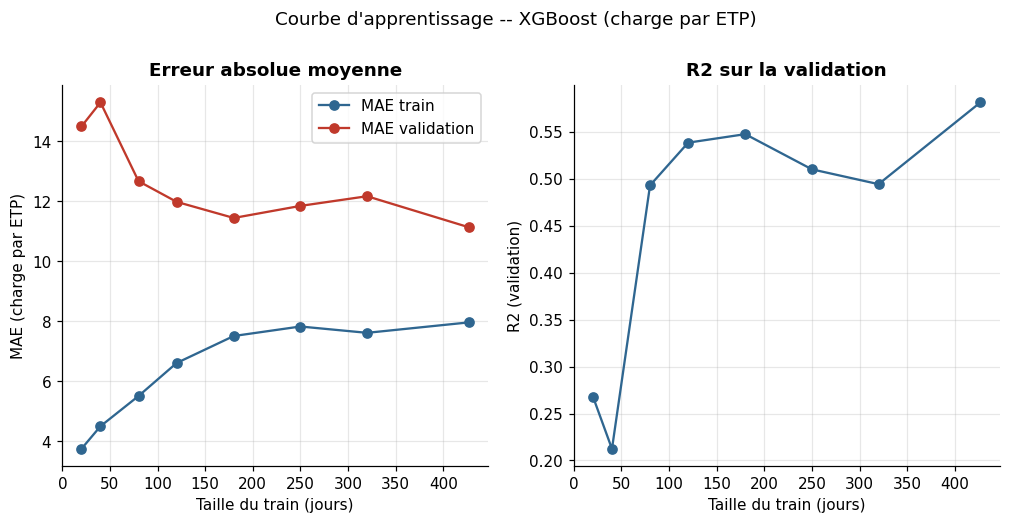

taille=  20  MAE_train=  3.75  MAE_val= 14.50  R2_val= 0.268
taille=  40  MAE_train=  4.51  MAE_val= 15.30  R2_val= 0.212
taille=  80  MAE_train=  5.51  MAE_val= 12.67  R2_val= 0.493
taille= 120  MAE_train=  6.61  MAE_val= 11.98  R2_val= 0.538
taille= 180  MAE_train=  7.51  MAE_val= 11.45  R2_val= 0.547
taille= 250  MAE_train=  7.83  MAE_val= 11.85  R2_val= 0.510
taille= 320  MAE_train=  7.62  MAE_val= 12.17  R2_val= 0.494
taille= 427  MAE_train=  7.97  MAE_val= 11.14  R2_val= 0.581


In [5]:
from sklearn.metrics import mean_absolute_error, r2_score
from xgboost import XGBRegressor

df_train, df_val, df_test = split_temporel(df_model)
print(f"train={len(df_train)}  val={len(df_val)}  test={len(df_test)}")

tailles = [20, 40, 80, 120, 180, 250, 320, len(df_train)]
mae_train, mae_val, r2_val = [], [], []
for taille in tailles:
    sous_train = df_train.iloc[:taille]
    m = XGBRegressor(n_estimators=29, max_depth=3, learning_rate=0.1, subsample=0.8,
                      colsample_bytree=1.0, min_child_weight=3, reg_alpha=0.1, reg_lambda=1.0,
                      random_state=42, verbosity=0)
    m.fit(sous_train[FEATURES], sous_train[TARGET])
    mae_train.append(mean_absolute_error(sous_train[TARGET], m.predict(sous_train[FEATURES])))
    mae_val.append(mean_absolute_error(df_val[TARGET], m.predict(df_val[FEATURES])))
    r2_val.append(r2_score(df_val[TARGET], m.predict(df_val[FEATURES])))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].plot(tailles, mae_train, marker="o", color=COULEUR_PRINCIPALE, label="MAE train")
axes[0].plot(tailles, mae_val, marker="o", color=COULEUR_ALERTE, label="MAE validation")
axes[0].set_xlabel("Taille du train (jours)")
axes[0].set_ylabel("MAE (charge par ETP)")
axes[0].legend()
axes[0].set_title("Erreur absolue moyenne")

axes[1].plot(tailles, r2_val, marker="o", color=COULEUR_PRINCIPALE)
axes[1].set_xlabel("Taille du train (jours)")
axes[1].set_ylabel("R2 (validation)")
axes[1].set_title("R2 sur la validation")
fig.suptitle("Courbe d'apprentissage -- XGBoost (charge par ETP)", y=1.03)
save(fig, BLOC, "04_courbe_apprentissage.png")
plt.show()

for t, tr, va, r2 in zip(tailles, mae_train, mae_val, r2_val):
    print(f"taille={t:4d}  MAE_train={tr:6.2f}  MAE_val={va:6.2f}  R2_val={r2:6.3f}")

**Lecture.** Le schema est le meme qu'au bloc 3A, en plus marque : a 20
jours de train, le modele colle presque parfaitement aux donnees (MAE train
= 3.75) mais explique a peine plus d'un quart de la variance en validation
(R2 = 0.268, MAE val = 14.50). Le passage a 40 jours degrade meme legerement
la validation (MAE val = 15.30, R2 = 0.212) avant de s'ameliorer nettement a
partir de 80 jours -- avec si peu de jours, le train ne couvre pas
forcement une fin de trimestre complete, or on vient de voir que c'est la
variable la plus discriminante du bloc apres la charge et le volume recents.
Entre 180 et 320 jours, la validation stagne, voire se degrade legerement
(MAE val remonte de 11.45 a 12.17 a 320 jours) : un signe que l'ajout de
donnees, a ce stade, n'apporte plus une information homogene mais melange des
periodes differentes que 427 jours seulement suffisent a peine a
stabiliser. Le meilleur resultat de toute la courbe arrive a taille maximale
(MAE val = 11.14, R2 = 0.581) -- donc XGBoost profite bien de plus de
donnees au global, mais la progression est heurtee, pas lisse. Un R2 plafonnant
a 0.581 meme a taille pleine, combine au fait que ce modele ne bat pas le
Ridge fixe de la configuration d'origine sur le jeu de test (11.28 contre
10.95, cf. `AMELIORATION_MODELES.md`), va dans le meme sens : ce bloc ne
souffre pas d'un manque de donnees d'entrainement -- il souffre plutot d'un
signal intrinsequement plus difficile a capter que les trois autres blocs, ce
qu'aucune quantite de donnees supplementaires ne resoudra a elle seule.

## Synthese du bloc

`charge_par_etp` est tres fortement liee au volume entrant (r=0.95) et,
dans une moindre mesure, a la part de dossiers complexes et aux cycles de
cloture trimestrielle -- les memes cycles que ceux identifies dans le bloc
3A. Les regresseurs d'incidents manager sont presents mais inertes sur ces
donnees (aucune saisie a ce jour). La courbe d'apprentissage confirme que le
XGBoost retenu beneficie globalement de plus de donnees, avec une
progression irreguliere plutot que lisse, et un plafond de performance
(R2~0.58) qui rejoint le constat deja documente : sur ce bloc precis, la
recherche d'hyperparametres et les features cycliques n'ont pas suffi a
depasser la configuration Ridge d'origine sur le test final.